# AMS-02 ECAL geometry fidelity

This notebook validates the **ideal detector geometry** used by the project before Stage II FastMC development.

The goal is to separate three concepts clearly:

1. **Documented detector geometry** — physical dimensions, sampling structure, readout topology, and effective bulk material properties.
2. **Idealized FastMC representation** — the detector is represented by 18 finite longitudinal readout slices and 72 transverse cells per slice.
3. **Detector conditions and response** — noise, gain drift, dead channels, optical attenuation, saturation, thresholds, alignment, and calibration are deliberately excluded here and will be introduced later as configurable effects.

The geometry therefore aims to be physically faithful without making the ideal simulation depend on real-world imperfections.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ams_ecal import load_geometry

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG_PATH = PROJECT_ROOT / "configs" / "geometry.yaml"
geometry = load_geometry(CONFIG_PATH)

print("Loaded:", CONFIG_PATH)

Loaded: C:\Users\ASUS\ams-ecal-qml\configs\geometry.yaml


## 1. Documented detector-scale quantities

The current geometry configuration encodes the AMS-02 ECAL as a lead/scintillating-fiber sampling calorimeter with:

- active readout area of $648 \times 648\ \mathrm{mm}^2$;
- active depth of $166.5\ \mathrm{mm}$;
- $9$ superlayers of $18.5\ \mathrm{mm}$ each;
- $17X_0$ total electromagnetic depth;
- $18$ longitudinal readout samplings, two per superlayer;
- $72$ transverse cells per sampling;
- $324$ four-anode PMTs, giving $1296$ readout cells;
- approximately $35$ fibers per $9\times9\ \mathrm{mm}^2$ cell.

The physical sampling structure contains 11 absorber-foil positions and 10 scintillating-fiber planes per superlayer. The final foil of the final superlayer is aluminum rather than lead, giving 98 lead foils plus one aluminum foil in total.

In [2]:
summary = {
    "active width x [mm]": geometry.width_x_mm,
    "active width y [mm]": geometry.width_y_mm,
    "active depth [mm]": geometry.depth_z_mm,
    "superlayers": geometry.number_of_superlayers,
    "readout layers": geometry.number_of_layers,
    "cells per layer": geometry.cells_per_layer,
    "total cells": geometry.total_cells,
    "PMT anodes": geometry.total_readout_anodes,
    "radiation lengths": geometry.total_depth_x0,
    "interaction lengths": geometry.total_depth_lambda_i,
    "effective critical energy [MeV]": (
        geometry.material_properties.effective_critical_energy_mev
    ),
}

for name, value in summary.items():
    print(f"{name:34s}: {value}")

active width x [mm]               : 648.0
active width y [mm]               : 648.0
active depth [mm]                 : 166.5
superlayers                       : 9
readout layers                    : 18
cells per layer                   : 72
total cells                       : 1296
PMT anodes                        : 1296
radiation lengths                 : 17.0
interaction lengths               : 0.6
effective critical energy [MeV]   : 7.6


## 2. Independent geometry cross-checks

Several detector facts describe the same structure independently. They are useful as invariants because disagreement would indicate a configuration or implementation error.

The transverse segmentation gives

$$
18\times72=1296
$$

readout cells.

The photomultiplier description independently gives

$$
324\times4=1296
$$

anodes.

Likewise, the physical depth must satisfy

$$
9\times18.5\ \mathrm{mm}=166.5\ \mathrm{mm}.
$$

The 9 superlayers contain

$$
9\times11=99
$$

absorber-foil positions. Since the final foil is aluminum,

$$
99-1=98
$$

positions contain lead.

In [3]:
assert geometry.total_cells == 18 * 72 == 1296
assert geometry.total_readout_anodes == 324 * 4 == 1296
assert geometry.total_cells == geometry.total_readout_anodes

assert np.isclose(
    geometry.number_of_superlayers
    * geometry.sampling_structure.superlayer_thickness_mm,
    geometry.depth_z_mm,
)

assert geometry.total_absorber_foil_positions == 99
assert geometry.number_of_lead_foils == 98
assert geometry.number_of_aluminum_foils == 1

print("All independent detector cross-checks passed.")

All independent detector cross-checks passed.


## 3. Alternating superlayer/readout topology

Each superlayer contains fibers running along only one transverse direction. In the package convention the nine physical superlayers follow

$$
(x,y,x,y,x,y,x,y,x).
$$

Each superlayer produces two longitudinal readout samplings, so the effective 18-layer sequence is

$$
(x,x,y,y,x,x,y,y,x,x,y,y,x,x,y,y,x,x).
$$

The fiber axis is **not** the measured coordinate: a fiber extending along $x$ localizes energy in $y$, and vice versa. Block 2 handles that readout convention.

Superlayer fiber axes:
('x', 'y', 'x', 'y', 'x', 'y', 'x', 'y', 'x')

Expanded 18-layer fiber axes:
('x', 'x', 'y', 'y', 'x', 'x', 'y', 'y', 'x', 'x', 'y', 'y', 'x', 'x', 'y', 'y', 'x', 'x')


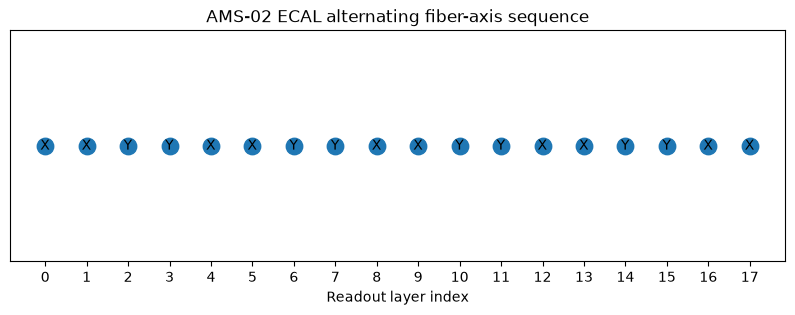

In [4]:
print("Superlayer fiber axes:")
print(geometry.superlayer_fiber_axes)

print("\nExpanded 18-layer fiber axes:")
print(geometry.layer_fiber_axes)

layer_indices = np.arange(geometry.number_of_layers)

plt.figure(figsize=(10, 3))
plt.scatter(
    layer_indices,
    np.zeros_like(layer_indices),
    s=140,
)
for layer_index, axis in enumerate(geometry.layer_fiber_axes):
    plt.text(
        layer_index,
        0.0,
        axis.upper(),
        ha="center",
        va="center",
    )

plt.yticks([])
plt.xticks(layer_indices)
plt.xlabel("Readout layer index")
plt.title("AMS-02 ECAL alternating fiber-axis sequence")
plt.show()

## 4. Finite longitudinal readout intervals

For FastMC we do **not** treat each readout layer as a homogeneous physical slab. The lead, fibers, and glue form a composite sampling structure inside each superlayer.

Instead, the 18 rows of the canonical ECAL array are treated as **effective finite longitudinal readout intervals** spanning the full detector depth.

Under the current uniform readout approximation,

$$
\Delta z = \frac{166.5\ \mathrm{mm}}{18}
          = 9.25\ \mathrm{mm},
$$

and

$$
\Delta t = \frac{17X_0}{18}
          \approx 0.9444X_0.
$$

This representation is important for Block 4. A continuous longitudinal shower density $f(t)$ will be integrated across each interval,

$$
F_\ell =
\int_{t_{\ell,\mathrm{low}}}^{t_{\ell,\mathrm{high}}}
f(t)\,dt,
$$

rather than sampled only at the layer center.

In [5]:
print(
    "Uniform readout slice:",
    f"{geometry.mean_readout_slice_thickness_mm:.4f} mm",
)
print(
    "Uniform readout slice:",
    f"{geometry.mean_readout_slice_thickness_x0:.6f} X0",
)

bounds = geometry.uniform_layer_bounds_x0

for layer_index, (lower, upper) in enumerate(bounds):
    print(
        f"layer {layer_index:2d}: "
        f"{lower:7.4f} -> {upper:7.4f} X0"
    )

Uniform readout slice: 9.2500 mm
Uniform readout slice: 0.944444 X0
layer  0:  0.0000 ->  0.9444 X0
layer  1:  0.9444 ->  1.8889 X0
layer  2:  1.8889 ->  2.8333 X0
layer  3:  2.8333 ->  3.7778 X0
layer  4:  3.7778 ->  4.7222 X0
layer  5:  4.7222 ->  5.6667 X0
layer  6:  5.6667 ->  6.6111 X0
layer  7:  6.6111 ->  7.5556 X0
layer  8:  7.5556 ->  8.5000 X0
layer  9:  8.5000 ->  9.4444 X0
layer 10:  9.4444 -> 10.3889 X0
layer 11: 10.3889 -> 11.3333 X0
layer 12: 11.3333 -> 12.2778 X0
layer 13: 12.2778 -> 13.2222 X0
layer 14: 13.2222 -> 14.1667 X0
layer 15: 14.1667 -> 15.1111 X0
layer 16: 15.1111 -> 16.0556 X0
layer 17: 16.0556 -> 17.0000 X0


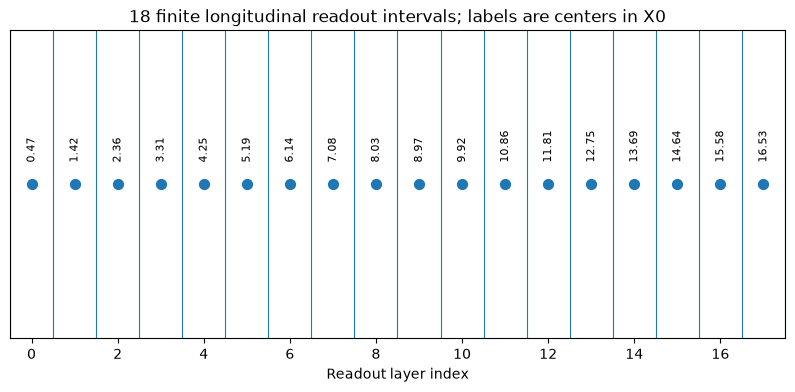

In [6]:
centers_x0 = np.array(
    [(lower + upper) / 2 for lower, upper in geometry.uniform_layer_bounds_x0]
)

plt.figure(figsize=(10, 4))
plt.vlines(
    np.arange(geometry.number_of_layers + 1) - 0.5,
    ymin=0,
    ymax=1,
    linewidth=0.8,
)
plt.scatter(
    np.arange(geometry.number_of_layers),
    np.full(geometry.number_of_layers, 0.5),
    s=50,
)
for layer_index, center_x0 in enumerate(centers_x0):
    plt.text(
        layer_index,
        0.58,
        f"{center_x0:.2f}",
        ha="center",
        rotation=90,
        fontsize=8,
    )

plt.xlim(-0.5, geometry.number_of_layers - 0.5)
plt.ylim(0, 1)
plt.yticks([])
plt.xlabel("Readout layer index")
plt.title("18 finite longitudinal readout intervals; labels are centers in X0")
plt.show()

## 5. Fiber packing and stagger

Within a fiber plane, neighboring rows are not aligned directly above each other. Adjacent rows are shifted by half the horizontal pitch.

With a horizontal pitch of $1.35\ \mathrm{mm}$ and stagger fraction $0.5$, the shift is

$$
0.5\times1.35\ \mathrm{mm}
=
0.675\ \mathrm{mm}.
$$

This packing detail is recorded now because it is a real detector property, even though Block 4 does not need fiber-level positions. It can become relevant for later lateral modeling or a Geant4 implementation.

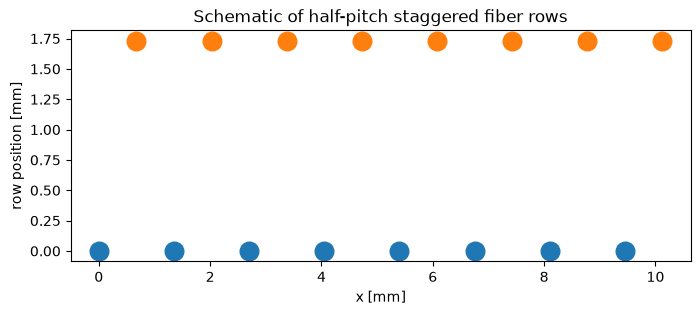

Half-pitch stagger: 0.675 mm


In [7]:
pitch = geometry.sampling_structure.fiber_horizontal_pitch_mm
row_spacing = geometry.sampling_structure.fiber_row_spacing_mm
stagger = geometry.sampling_structure.adjacent_row_stagger_fraction * pitch

row_0_x = np.arange(8) * pitch
row_1_x = np.arange(8) * pitch + stagger

plt.figure(figsize=(8, 3))
plt.scatter(row_0_x, np.zeros_like(row_0_x), s=180)
plt.scatter(row_1_x, np.full_like(row_1_x, row_spacing), s=180)

plt.xlabel("x [mm]")
plt.ylabel("row position [mm]")
plt.title("Schematic of half-pitch staggered fiber rows")
plt.show()

print(f"Half-pitch stagger: {stagger:.3f} mm")

## 6. Effective composite material properties

The lead/fiber/glue composite is stored using the documented relative volume ratio

$$
1:0.57:0.15.
$$

Those numbers are ratios, not already-normalized fractions. The geometry object therefore retains the original values and derives normalized fractions only when a calculation needs them.

The ideal geometry also stores the test-beam-derived effective critical energy,

$$
E_c = 7.6\ \mathrm{MeV},
$$

which will be consumed by the Stage II electromagnetic shower model rather than duplicated in a FastMC configuration.

In [8]:
lead, fiber, glue = (
    geometry.material_properties.normalized_volume_fractions
)

print(f"lead volume fraction : {lead:.5f}")
print(f"fiber volume fraction: {fiber:.5f}")
print(f"glue volume fraction : {glue:.5f}")
print(f"sum                  : {lead + fiber + glue:.5f}")

assert np.isclose(lead + fiber + glue, 1.0)

lead volume fraction : 0.58140
fiber volume fraction: 0.33140
glue volume fraction : 0.08721
sum                  : 1.00000


## 7. What this geometry deliberately does not model

The ideal detector geometry is intentionally separated from **detector response and detector conditions**.

The following effects are not geometry constants and are not enabled at this stage:

- optical attenuation and light-collection nonuniformity;
- photoelectron statistics and electronics response;
- noise and readout thresholds;
- fiber/photodetector saturation;
- dead or noisy channels;
- channel-to-channel gain corrections;
- temperature-dependent calibration;
- time-dependent detector conditions;
- tracker-to-ECAL alignment corrections.

This separation lets later studies compare

**ideal shower physics → ideal AMS geometry**

against progressively more realistic configurations without changing the underlying detector definition.

## 8. Fidelity boundary

This geometry is more detailed than the original Block 0 representation but remains a **FastMC detector model**, not a microscopic transport geometry.

In particular:

- the physical lead/fiber/glue construction is recorded, but individual fibers are not transport volumes;
- the 18 longitudinal rows are effective readout intervals, not homogeneous material slabs;
- real flight channel identifiers and run-dependent calibration constants are not yet available;
- Geant4 will later provide the higher-fidelity particle-transport reference.

These approximations must remain explicit when comparing FastMC with Geant4 or future AMS flight data.

## References

Detector quantities encoded by this notebook are based primarily on:

1. AMS Collaboration, **The Electromagnetic Calorimeter (ECAL)**  
   https://www.ams02.space/detector/electromagnetic-calorimeter-ecal

2. AMS Collaboration, **New Reconstruction Method in the Electromagnetic Calorimeter (ECAL) Analysis**  
   https://ams02.space/advances-data-analysis/new-reconstruction-method-electromagnetic-calorimeter-ecal-analysis

3. M. Vecchi et al., **The electromagnetic calorimeter of the AMS-02 experiment**, Astroparticle Physics 45 (2013) 6–14.  
   https://arxiv.org/abs/1210.0316

4. C. Adloff et al./AMS ECAL group, **Performance of the AMS02 Electromagnetic Calorimeter in space**, CALOR2012, including the test-beam-derived effective critical energy and radiation-length measurements.  
   DOI: 10.1088/1742-6596/404/1/012034

When collaboration-provided geometry, alignment, channel maps, or calibration constants become available, those sources should supersede public approximations where appropriate.